# Verkennen CliNLP
---
Auteur:   Eva Rombouts  
Datum:    8-11-2023.  
Doel:     Verkennen CliNLP  
Resources:  
- [ClinNLP Github](https://github.com/umcu/clinlp/tree/main)
---

## Setup

### Laad libraries

In [1]:
# Duurt ook nog best een tijdje, 20 sec ofzo
import pandas as pd
import re
import os

import spacy
from transformers import pipeline 

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Laad data

In [2]:
wdn = pd.read_csv("../data/wdn.csv")

### Laad taalmodel

In [3]:
# Laad het Nederlandse taalmodel
nlp = spacy.load("nl_core_news_sm")

### Parameters / variabelen

In [4]:
# Parameters / variabelen
seed = 6
sample_size = 1000

## Data wrangling
Maak een nieuwe df waarderingen:
- Met een random sample (size hierboven gedefinieerd)
- Selecteer alleen de datum, tekst en beoordeling
- We bewaren alleen waarderingen van na 2015, daarvoor w

In [5]:
def beperk_tekst(tekst, max_woorden=200):
    woorden = tekst.split()[:max_woorden]  # Splits de tekst in woorden en neem de eerste 255
    return ' '.join(woorden)  # Voeg de woorden weer samen tot een string

waarderingen = (wdn
          .sample(n=sample_size, random_state=seed)
          .rename(columns={'toelichting': 'tekst', 'gemiddelde': 'waardering'})
          .assign(waardering=lambda x: x['waardering'].round(1),
                  datum=lambda x: pd.to_datetime(x['datum'], errors='coerce'),
                  tekst=lambda x: x['tekst'].apply(beperk_tekst))
          .query("datum > '2015-12-31'")
          [['id', 'datum', 'tekst', 'waardering']]
          .dropna()
)

In [6]:
waarderingen.head()
print(waarderingen.iloc[2,2])

Kan beter: Minder personeelswisselingen meer dezelfde mensen aan bed en meer capaciteit zodat lagere werkdruk is en ook meer tijd voor onderlinge overdracht zodat nieuwe medewerkers weten wat ze moeten doen. Tevreden over: Goede verzorging


## Modellen zoeken

### Sentiment analyse Wietse de Vries
wietsedv/bert-base-dutch-cased-finetuned-sentiment

In [7]:
model = 'wietsedv/bert-base-dutch-cased-finetuned-sentiment'

sentiment_analysis = pipeline('sentiment-analysis', model = model)

In [8]:
test_zinnen = [
    "Mijn oma is dolgelukkig in haar nieuwe verzorgingshuis, de zorg is uitmuntend en het personeel is zeer attent.",
    "De activiteiten in het verzorgingshuis zijn verrijkend en zorgen voor een levendige gemeenschap.",
    "De kamers zijn adequaat, maar ik vind dat het verzorgingshuis wel wat modernisering kan gebruiken.",
    "Ik ben bezorgd over de kwaliteit van de maaltijden en de schoonmaak in het verzorgingshuis waar mijn vader verblijft.",
    "Ik ben geschokt door de verwaarlozing die ik heb waargenomen in het verzorgingshuis; dit is onaanvaardbaar en moet aangepakt worden."
]

se_output = sentiment_analysis(test_zinnen)

for a in enumerate(se_output) :
    print(a)

(0, {'label': 'pos', 'score': 0.9999958276748657})
(1, {'label': 'pos', 'score': 0.9999964237213135})
(2, {'label': 'pos', 'score': 0.9669678807258606})
(3, {'label': 'neg', 'score': 0.9999274015426636})
(4, {'label': 'neg', 'score': 0.9998555183410645})


Hm, niet heel goed in staat om subtiele reviews te begrijpen, maar het begin is er..
De betekenis van 'score' snap ik ook nog niet...

In [9]:
#Duurt een klein minuutje voor 1000 waarderingen
se_output = sentiment_analysis(list(waarderingen['tekst']))

Voeg het sentiment lable en de sentiment score toe aan de df. 
Ik bereken een logit_score omdat de sentiment score eigenlijk steeds tegen de 1 aanzit... Waarom dit precies is snap ik nog niet zo goed. 

In [10]:
waarderingen['sentiment'] = [d['label'] for d in se_output]
waarderingen['sentiment_score'] = [d['score'] for d in se_output]
waarderingen['logit_score'] = waarderingen['sentiment_score'].apply(lambda x: np.log(x / (1 - x)))

In [11]:
print(waarderingen.groupby('sentiment')['waardering'].describe())

           count      mean       std  min  25%  50%  75%   max
sentiment                                                     
neg        229.0  7.201747  1.443283  1.0  6.7  7.5  8.2  10.0
pos        563.0  8.349201  1.042348  1.5  7.8  8.3  9.0  10.0


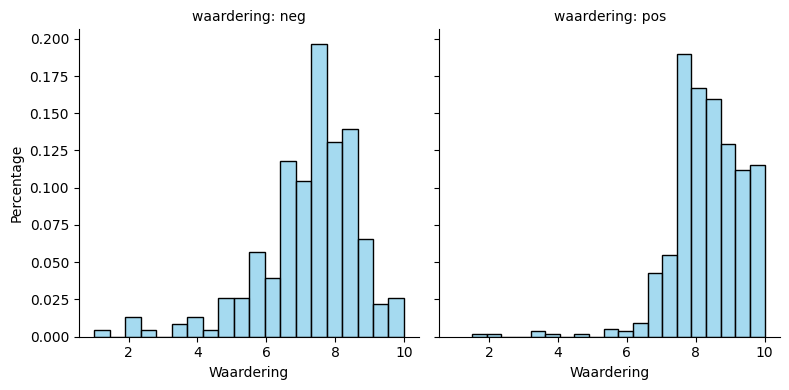

In [12]:
# Maak een FacetGrid, gescheiden door sentiment, met de histogrammen naast elkaar
g = sns.FacetGrid(waarderingen, col='sentiment', height=4, aspect=1)

# Maak een histogram op elke facet met een rustige kleur en randjes om de bars
# en gebruik de 'probability' om de y-as als percentage te tonen
g.map(sns.histplot, 'waardering', bins=20, color='skyblue', edgecolor='black', stat='probability')

# Voeg titels toe en pas de aslabels aan
g.set_titles('waardering: {col_name}')
g.set_axis_labels('Waardering', 'Percentage')

# Pas de layout aan en toon de plot
plt.tight_layout()
plt.show()


Doet het niet heel erg goed...
Leren om te finetunen...

### Question answering Henry K Bert base multilingual

In [13]:
jansen = """Mevrouw Jansen leek vandaag enigszins verward bij het ontwaken. 
Ze had assistentie nodig bij het wassen en aankleden, wat rustig en met geduld is verlopen. 
Ze werd vriendelijk herinnerd aan het gebruik van haar rollator, en ze accepteerde de hulp hierbij. 
Incontinentie van urine was vandaag aan de orde; we hebben het incontinentiemateriaal frequent verschoond. 
Vandaag was Mevrouw Jansen vrij helder en kon zich de namen van de verzorgenden herinneren. 
Ze had hulp nodig bij haar persoonlijke hygiëne en aankleden, maar was coöperatief. 
Ze vergat aanvankelijk haar rollator, maar na een korte herinnering gebruikte ze deze correct. 
Incontinentiemateriaal is volgens protocol vervangen. Gedurende de ochtend vertoonde Mevrouw Jansen tekenen van verwarring; 
ze was haar kamerdeur kwijt. Na begeleiding en geruststelling kon ze zich aankleden met ondersteuning. 
Ze heeft haar rollator zelfstandig gepakt na een subtiele hint. Incontinentiezorg was nodig en is verleend.
Mevrouw Jansen was vandaag ontstemd en leek haar situatie niet goed te begrijpen. 
Ze was resistent tegen hulp bij het wassen, maar accepteerde uiteindelijk de ondersteuning. 
Meerdere keren herinnerd aan haar rollator, wat ze na enige tijd accepteerde. """

In [14]:
model="henryk/bert-base-multilingual-cased-finetuned-dutch-squad2"

qa_pipeline = pipeline(
    "question-answering",
    model = model,
    tokenizer = model
)

qa_pipeline({
    'context': jansen,
    'question': "Welke ADL hulp heeft mw Jansen nodig?"})


Some weights of the model checkpoint at henryk/bert-base-multilingual-cased-finetuned-dutch-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{'score': 0.07955287396907806,
 'start': 487,
 'end': 520,
 'answer': 'persoonlijke hygiëne en aankleden'}

In [15]:
# Functie die op elke rij zal worden toegepast
def answer_question(row):
    result = qa_pipeline({
        'context': row['tekst'],
        'question': "Vat samen"
    })
    return result['answer']

# Pas toe op waarderingen
waarderingen['antwoord'] = waarderingen.apply(answer_question, axis=1)


In [16]:
(waarderingen
 .sort_values(by='waardering', ascending=True)
 .head(20))


,id,datum,tekst,waardering,sentiment,sentiment_score,logit_score,antwoord
165071,165072,2016-10-13,"Mistroostig gebouw, sobere kamers.Geen voorzie...",1.0,neg,0.999952,9.935984,vrijwilligers
48769,48770,2018-08-10,Ik heb lang geloofd in deze zorginstelling maa...,1.5,pos,0.999984,11.022388,het staken van hartmedicatie + cholesterolverl...
105024,105025,2021-10-01,Gemaakte afspraken (die ook geregistreerd word...,2.0,neg,0.999956,10.028838,Gemaakte afspraken
57952,57953,2018-09-03,Vader hier paar weken verbleven wegens omstand...,2.2,pos,0.998812,6.734262,Vader
42662,42663,2022-10-05,ik kan spreken over de zorg op de 3e etage en ...,2.2,neg,0.999940,9.723725,"zoveel miscommunicatie, evaluaties met zorg"
32142,32143,2020-01-13,Zeer slechte ervaringen met Berchhiem. Mijn va...,2.3,neg,0.999451,7.505961,koffievlekken zaten op de muren
134846,134847,2016-07-07,Zeer slechte instelling. Ondeskundig en onvrie...,2.7,neg,0.999939,9.707914,Ondeskundig en onvriendelijk personeel
15685,15686,2022-03-29,Ontevreden manager die niet op komt voor medeb...,3.2,pos,0.998033,6.229513,medebewoners
57902,57903,2021-05-24,Ik zou niemand deze locatie aanbevelen na de e...,3.3,neg,0.999840,8.743294,Bedranden niet omhoog zetten met vallen met ve...
47828,47829,2019-03-26,Verschrikkelijk als je wat krijgt word je aan ...,3.3,pos,0.999996,12.476645,lot


### CliNLP

In [17]:
from clinlp import Normalizer, Sentencizer

# Initialisatie van de spaCy pipeline met clinlp componenten
nlp = spacy.blank("clinlp")
nlp.add_pipe("clinlp_normalizer")
nlp.add_pipe("clinlp_sentencizer")

# Functie om de pipeline toe te passen op de tekst
def process_text(text):
    doc = nlp(text)
    # Hier kunt u extra verwerking toevoegen om de gewenste informatie uit 'doc' te extraheren
    # Bijvoorbeeld: genormaliseerde tekst, gesplitste zinnen, etc.
    return doc

# Pas de functie toe op de 'tekst' kolom en sla het resultaat op in een nieuwe kolom
waarderingen['processed_text'] = waarderingen['tekst'].apply(process_text)

# Bekijk de eerste paar rijen van de DataFrame om het resultaat te controleren
print(waarderingen[['tekst', 'processed_text']].head())


                                                    tekst  \
86594   Ik wil wel eens uit, maar omdat er te weinig v...   
162452  Ik woon hier samen met mijn vrouw. De omgang m...   
36899   Kan beter: Minder personeelswisselingen meer d...   
125275  Ik ben zeer tevreden over de zorg voor mijn mo...   
34710   Mijn moeder heeft 4 jaar gewoond op de afdelin...   

                                           processed_text  
86594   (Ik, wil, wel, eens, uit, ,, maar, omdat, er, ...  
162452  (Ik, woon, hier, samen, met, mijn, vrouw, ., D...  
36899   (Kan, beter, :, Minder, personeelswisselingen,...  
125275  (Ik, ben, zeer, tevreden, over, de, zorg, voor...  
34710   (Mijn, moeder, heeft, 4, jaar, gewoond, op, de...  


In [18]:
df = waarderingen.iloc[:,0:4]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 792 entries, 86594 to 85770
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          792 non-null    int64         
 1   datum       792 non-null    datetime64[ns]
 2   tekst       792 non-null    object        
 3   waardering  792 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 30.9+ KB


In [19]:
# Voeg een entiteitsherkenner toe aan de pipeline
nlp.add_pipe("clinlp_entity_recognizer")

# Voeg een contextuele analyser toe aan de pipeline
nlp.add_pipe("clinlp_contextualizer")

# Functie om entiteiten en hun context te extraheren
def extract_entities_and_context(text):
    doc = nlp(text)
    entities = [(ent.text, ent.label_, ent._.contextual_attributes) for ent in doc.ents]
    return entities

# Pas de functie toe op de 'tekst' kolom en sla het resultaat op in een nieuwe kolom
df['entities_with_context'] = df['tekst'].apply(extract_entities_and_context)

# Bekijk de eerste paar rijen van de DataFrame om het resultaat te controleren
print(df.head())


ValueError: [E002] Can't find factory for 'clinlp_entity_recognizer' for language Clinlp (clinlp). This usually happens when spaCy calls `nlp.create_pipe` with a custom component name that's not registered on the current language class. If you're using a Transformer, make sure to install 'spacy-transformers'. If you're using a custom component, make sure you've added the decorator `@Language.component` (for function components) or `@Language.factory` (for class components).

Available factories: attribute_ruler, tok2vec, merge_noun_chunks, merge_entities, merge_subtokens, token_splitter, doc_cleaner, parser, beam_parser, lemmatizer, trainable_lemmatizer, entity_linker, entity_ruler, tagger, morphologizer, ner, beam_ner, senter, sentencizer, spancat, spancat_singlelabel, span_finder, future_entity_ruler, span_ruler, textcat, textcat_multilabel, nl.lemmatizer, clinlp_entity_matcher, clinlp_normalizer, clinlp_context_algorithm, clinlp_negation_transformer, clinlp_sentencizer

In [ ]:
import spacy
from clinlp import Term

nlp = spacy.blank("clinlp")
nlp.add_pipe("clinlp_normalizer")
nlp.add_pipe("clinlp_sentencizer")

# Entities
concepts = {
    "prematuriteit": [
        "preterm", "<p3", "prematuriteit", "partus praematurus"
    ],
    "hypotensie": [
        "hypotensie", Term("bd verlaagd", proximity=1)
    ],
    "veneus_infarct": [
        "veneus infarct", Term("VI", attr="TEXT")
    ],
    "dementie": [
        "dementie", "alzheimer", "vasculaire dementie", "frontotemporale dementie",
        "Lewy body dementie", "mild cognitive impairment"
    ],
    "incontinentie": [
        "incontinentie", "incontinent", 
        Term("urineverlies", attr="NORM"),
        Term("fecale incontinentie", attr="NORM"),
        Term("ontlastingverlies", attr="NORM"),
        [
            {"NORM": {"FUZZY1": "zat"}},
            {"LOWER": {"IN": ["onder", "vol"]}},
            {"NORM": {"FUZZY1": "def"}},
        ],
        [
            {"NORM": "verschoond"},
            {"OP": "?"},
            {"LOWER": "dhr", "OP": "?"},
            {"LOWER": "mvr", "OP": "?"},
            {"LOWER": "patiënt", "OP": "?"},
        ],
    ]
}

entity_matcher = nlp.add_pipe("clinlp_entity_matcher", config={"attr": "NORM", "fuzzy": 1})
entity_matcher.load_concepts(concepts)

# Qualifiers
nlp.add_pipe("clinlp_context_algorithm", config={"phrase_matcher_attr": "NORM"})

# text = (
#     "Patiënt vertoont tekenen van milde cognitieve achteruitgang, mogelijk vroege "
#     "stadium van Alzheimer. Familiegeschiedenis van vasculaire dementie. "
#     "Geen aanwijzingen voor Lewy body dementie."
# )

text = """ 
De heer Jansen werd opgenomen met symptomen van een delier; hij hoorde stemmen die er niet waren. 
Tijdens de nacht was meneer onrustig en zag dingen op de muur die er niet echt waren, wat wijst op hallucinaties. 
Daarnaast was er een incident waarbij de heer Jansen onder de def zat en verschoond moest worden. Dit duidt op mogelijke 
fecale incontinentie. Verder is er sprake van urineverlies, wat wijst op urinaire incontinentie. 
De DOS-schaal is gebruikt om de ernst van het delier te beoordelen."
"""

doc = nlp(text)

In [ ]:
from spacy import displacy

displacy.render(doc, style="ent")

In [ ]:
for ent in doc.ents:
  print(ent, ent._.qualifiers_str)

In [ ]:
waarderingen_docs = [nlp(tekst) for tekst in waarderingen['tekst']]

In [ ]:
print(len(waarderingen_docs))
print(waarderingen.shape)

792
(792, 9)


In [ ]:
for doc in waarderingen_docs:
    for ent in doc.ents:
        print(ent.text, ent.label_)



Alzheimer dementie
Dementie dementie
dementie dementie
incontinent incontinentie
demetie dementie
dat onder de incontinentie
verschoond. incontinentie
. 3 prematuriteit
dementie dementie
Alzheimer dementie
verschoond werd incontinentie
Dementie dementie
demente dementie
/3 prematuriteit
dementie dementie
dementie dementie
dementie dementie
dementie dementie
dementie dementie
dementie dementie
dementie dementie
demente dementie
Alzheimer dementie
dementie dementie
I veneus_infarct
alzheimer dementie
Alzheimer dementie
dementie dementie
dementia dementie
verschoond. incontinentie
demente dementie
Dementie dementie
incontinent incontinentie
alzheimer dementie
altzheimer dementie
demente dementie


In [ ]:
waarderingen_docs[1]

Ik woon hier samen met mijn vrouw. De omgang met de medewerkers is goed. Ze zijn vriendelijk en behulpzaam. De verpleging is ook goed. De mensen zijn zeer deskundig en weten wat ze doen. Ik heb gelukkig niet veel zorg nodig. De afspraken worden goed nagekomen. Ik krijg mijn medicijnen op tijd en ik word gedoucht. De kwaliteit van leven is goed. Het sluit prima bij mij aan en past goed bij mij. De accommodatie is prima; ook beneden in het restaurant is het goed. Het eten is geweldig en smaakt prima. De schoonmaak kan beter. Mijn kamer is mooi, daar ben ik tevreden mee. Er wordt goed naar mij geluisterd. Ik hoef het maar te vragen en het wordt gedaan.

In [ ]:
# Maak een lijst van dictionaries voor elke entiteit in elk document
entiteiten_data = []
for doc in waarderingen_docs:
    for ent in doc.ents:
        entiteiten_data.append({"Tekst": ent.text, "Label": ent.label_})

# Converteer de lijst van dictionaries naar een DataFrame
entiteiten_df = pd.DataFrame(entiteiten_data)

In [ ]:
# Verwerk de teksten en verzamel de entiteiten en qualifiers
entiteiten_data = []
for i, tekst in enumerate(waarderingen['tekst']):
    doc = nlp(tekst)
    for ent in doc.ents:
        entiteiten_data.append({
            "Index": i,  # Index om later te koppelen met de oorspronkelijke DataFrame
            "Entiteit": ent.text,
            "Label": ent.label_,
            "Qualifiers": ent._.qualifiers_str  # Aanname dat qualifiers beschikbaar zijn als een extensie
        })

# Maak een DataFrame van de verzamelde gegevens
entiteiten_df = pd.DataFrame(entiteiten_data)

# Koppel de nieuwe DataFrame met de oorspronkelijke DataFrame
waarderingen_entiteiten_df = waarderingen.merge(entiteiten_df, left_index=True, right_on="Index")

# Toon de gekoppelde DataFrame
entiteiten_df['Qualifiers'].head()


0    {Plausibility.Plausible, Negation.Affirmed, Te...
1    {Plausibility.Plausible, Negation.Affirmed, Te...
2    {Temporality.Historical, Plausibility.Plausibl...
3    {Negation.Negated, Plausibility.Plausible, Tem...
4    {Plausibility.Plausible, Negation.Affirmed, Te...
Name: Qualifiers, dtype: object

In [ ]:
# Verwerk de teksten en verzamel de entiteiten en qualifiers
entiteiten_data = []
for i, tekst in enumerate(waarderingen['tekst']):
    doc = nlp(tekst)
    for ent in doc.ents:
        qualifiers_set = ent._.qualifiers_str  # Aanname dat qualifiers beschikbaar zijn als een string van sets
        qualifiers_dict = {"Plausibility": None, "Negation": None, "Temporality": None}

        # Verwerk de qualifiers set en vul de waarden in
        for qualifier in qualifiers_set:
            if "Plausibility" in qualifier:
                qualifiers_dict["Plausibility"] = qualifier
            elif "Negation" in qualifier:
                qualifiers_dict["Negation"] = qualifier
            elif "Temporality" in qualifier:
                qualifiers_dict["Temporality"] = qualifier

        entiteiten_data.append({
            "Index": i,
            "Entiteit": ent.text,
            "Label": ent.label_,
            **qualifiers_dict  # Voeg de qualifiers toe
        })

# Maak een DataFrame van de verzamelde gegevens
entiteiten_df = pd.DataFrame(entiteiten_data)

entiteiten_df.head()


,Index,Entiteit,Label,Plausibility,Negation,Temporality
0,39,Alzheimer,dementie,Plausibility.Plausible,Negation.Affirmed,Temporality.Current
1,39,Dementie,dementie,Plausibility.Plausible,Negation.Affirmed,Temporality.Current
2,53,dementie,dementie,Plausibility.Plausible,Negation.Affirmed,Temporality.Historical
3,98,incontinent,incontinentie,Plausibility.Plausible,Negation.Negated,Temporality.Current
4,150,demetie,dementie,Plausibility.Plausible,Negation.Affirmed,Temporality.Current


In [ ]:
print(waarderingen.iloc[53,2])

Mijn moeder van 93 jaar is voor 5 mnd in verpleeghuis de Rubroek geweest op de 4e etage Noord open afdeling beginnende dementie. In beging gelijk al goed ontvangen met koffie, thee, wat te eten en een bosje bloemen. In deze maanden is mijn moeder door het vaste personeel, heel goed verzorgd. Moeder zag er altijd netjes en verzorgd uit. Het eten is er goed, dat van uit het restaurant van beneden naar boven komt. Aan dagen zoals Sinterklaas en Kerst, is veel aandacht aan besteed. Ook klene exstratjes tussen door op de afdeling. Mijn moeder is overleden aan een longontsteking, ook tijdens de dagen dat ze ziek was is er extra aandacht aan haar besteed, met de juiste zorg, ook met de afdelingsarts waren goede gesprekken mogelijk. Hier wil ik hun dan ook allemaal hartelijk voor bedanken.Jammer van Enkele flexmedewerkers/oproepkrachten die die de kantjes er vanaf lopen, en hun mobieltje beter kunnen inleveren bij de verantwoordelijke tijdens hun werk. En een paar waarvan de zin er niet van af